In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
prefix = "PAIR_BEAM_"
shot_types = ["ARGON_", "PLASMA_"]
devices = ["HRM5", "HRM6"]

In [21]:
data_dict = {}

for shot_type in shot_types:
    for device in devices:
        name = shot_type+device
        path = os.path.join(prefix+shot_type+device + '.csv')
        if not os.path.exists(path):
            raise NotImplementedError(f"{path} doesn't exist")
        data_dict[name]=pd.read_csv(path)

data_dict[name]

,Unnamed: 0,LINEOUT AVG,LINEOUT STD
0,0,10625.659437,402.691848
1,1,18984.526275,434.485436
2,2,26307.114475,496.789181
3,3,30617.843474,504.890497
4,4,31583.895293,510.891688
...,...,...,...
395,395,12256.633958,326.298765
396,396,12247.971781,329.737520
397,397,12080.919517,335.027944
398,398,10026.385960,325.145873


----ARGON_HRM5----
MEAN: 19578.19310281507
STD: 5723.746947344478
MIN: 6980.172444541551
MAX: 29959.573225181943
--------

----PLASMA_HRM5----
MEAN: 20170.38903289328
STD: 5899.467138933527
MIN: 7177.922840082829
MAX: 30867.79390535521
--------



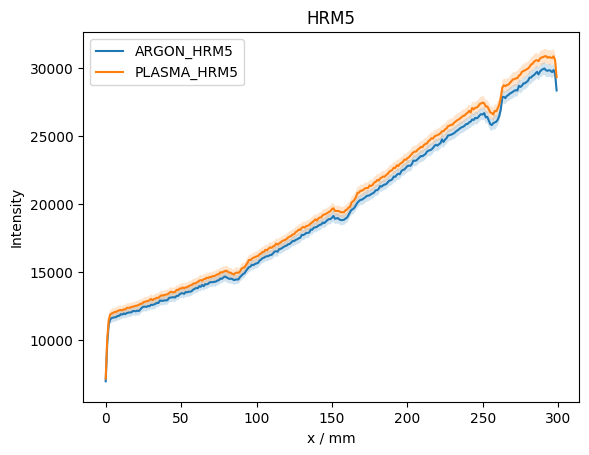

----ARGON_HRM6----
MEAN: 19432.8079007405
STD: 5798.816346689015
MIN: 6727.777222593039
MAX: 31091.65857650882
--------

----PLASMA_HRM6----
MEAN: 19979.149035969233
STD: 5985.665868421847
MIN: 6772.000926347461
MAX: 31989.197541162397
--------



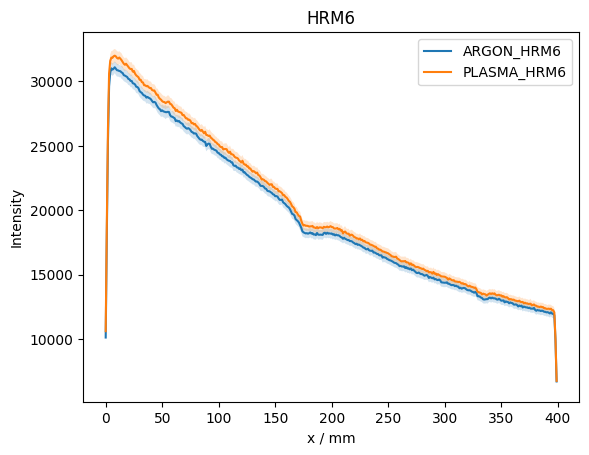

In [32]:
def display_stats(y:np.ndarray, name:str)->None:
    strings = [f"----{name}----", 
               f"MEAN: {np.mean(y)}", 
               f"STD: {np.std(y)}", 
               f"MIN: {np.min(y)}", 
               f"MAX: {np.max(y)}", f"--------\n"
               ]
    
    for string in strings:
        print(string)

def device_plot(device_name:str)->None:
    
    for i, shot_type in enumerate(shot_types):
        name = shot_type+device_name
        series = data_dict[name]
        xmax = len(series["LINEOUT AVG"])
        x = np.arange(xmax)

        y = series["LINEOUT AVG"]
        y1 = y - series["LINEOUT STD"]
        y2  = y + series["LINEOUT STD"]
        display_stats(y, name)

        plt.plot(x, y, label=name)
        plt.fill_between(x, y1, y2, alpha=0.2)
    plt.legend()
    plt.xlabel("x / mm")
    plt.ylabel("Intensity")
    plt.title(f"{device_name}")
    plt.savefig(device_name, dpi=300)
    plt.show()

for device in devices:
    device_plot(device_name=device)